**Project 2. Breast Cancer Diagnosis**

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set

**File:** `breast_cancer_dataset.csv`

**Dataset details:** https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

**1. SetUp**

In [28]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
# importing the dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
#configuration 
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:'%3f' %x)
sns.set_theme(style= "darkgrid")
RANDOM_STATE = 42

**2. Load Data**

In [31]:
df = pd.read_csv("breast_cancer_dataset.csv")

In [32]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990000,10.380000,122.800000,1001.000000,0.118400,0.277600,0.300100,0.147100,0.241900,0.078710,1.095000,0.905300,8.589000,153.400000,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380000,17.330000,184.600000,2019.000000,0.162200,0.665600,0.711900,0.265400,0.460100,0.118900
1,842517,M,20.570000,17.770000,132.900000,1326.000000,0.084740,0.078640,0.086900,0.070170,0.181200,0.056670,0.543500,0.733900,3.398000,74.080000,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990000,23.410000,158.800000,1956.000000,0.123800,0.186600,0.241600,0.186000,0.275000,0.089020
2,84300903,M,19.690000,21.250000,130.000000,1203.000000,0.109600,0.159900,0.197400,0.127900,0.206900,0.059990,0.745600,0.786900,4.585000,94.030000,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570000,25.530000,152.500000,1709.000000,0.144400,0.424500,0.450400,0.243000,0.361300,0.087580
3,84348301,M,11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,0.495600,1.156000,3.445000,27.230000,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000
4,84358402,M,20.290000,14.340000,135.100000,1297.000000,0.100300,0.132800,0.198000,0.104300,0.180900,0.058830,0.757200,0.781300,5.438000,94.440000,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540000,16.670000,152.200000,1575.000000,0.137400,0.205000,0.400000,0.162500,0.236400,0.076780


In [33]:
df.shape

(569, 32)

In [34]:
df = df.drop(columns="id")

In [35]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.990000,10.380000,122.800000,1001.000000,0.118400,0.277600,0.300100,0.147100,0.241900,0.078710,1.095000,0.905300,8.589000,153.400000,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380000,17.330000,184.600000,2019.000000,0.162200,0.665600,0.711900,0.265400,0.460100,0.118900
1,M,20.570000,17.770000,132.900000,1326.000000,0.084740,0.078640,0.086900,0.070170,0.181200,0.056670,0.543500,0.733900,3.398000,74.080000,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990000,23.410000,158.800000,1956.000000,0.123800,0.186600,0.241600,0.186000,0.275000,0.089020
2,M,19.690000,21.250000,130.000000,1203.000000,0.109600,0.159900,0.197400,0.127900,0.206900,0.059990,0.745600,0.786900,4.585000,94.030000,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570000,25.530000,152.500000,1709.000000,0.144400,0.424500,0.450400,0.243000,0.361300,0.087580
3,M,11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,0.495600,1.156000,3.445000,27.230000,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000
4,M,20.290000,14.340000,135.100000,1297.000000,0.100300,0.132800,0.198000,0.104300,0.180900,0.058830,0.757200,0.781300,5.438000,94.440000,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540000,16.670000,152.200000,1575.000000,0.137400,0.205000,0.400000,0.162500,0.236400,0.076780


**3. Exploratory Data Analysis**

In [36]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [37]:
# checking the number of the null value
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [39]:
# check if there is any encoded missing values - top repeated value
for col in df.columns:
    print(df[col].value_counts().head(10))

diagnosis
B    357
M    212
Name: count, dtype: int64
radius_mean
12.340000    4
13.000000    3
12.460000    3
13.170000    3
13.050000    3
12.180000    3
11.600000    3
13.850000    3
15.460000    3
12.770000    3
Name: count, dtype: int64
texture_mean
15.700000    3
16.840000    3
19.830000    3
20.520000    3
18.220000    3
14.930000    3
17.460000    3
18.900000    3
16.850000    3
21.250000    2
Name: count, dtype: int64
perimeter_mean
82.610000     3
87.760000     3
134.700000    3
132.900000    2
130.000000    2
132.400000    2
103.700000    2
102.500000    2
102.400000    2
87.320000     2
Name: count, dtype: int64
area_mean
512.200000     3
658.800000     2
684.500000     2
520.000000     2
559.200000     2
1076.000000    2
561.000000     2
394.100000     2
506.300000     2
1075.000000    2
Name: count, dtype: int64
smoothness_mean
0.100700    5
0.107500    4
0.105400    4
0.115000    4
0.109600    3
0.117000    3
0.098310    3
0.102400    3
0.108200    3
0.109900    3
Name: 

In [40]:
# identify duplicate rows
duplicate_marks = df.duplicated()
num_duplicate = duplicate_marks.sum()

print("Number of duplicate rows :",num_duplicate)
print("Duplicated row :\n",df[duplicate_marks])

Number of duplicate rows : 0
Duplicated row :
 Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []


In [41]:
# if you want to remove the duplicate rows
df_no_duplicate = df.drop_duplicates()
print("Shape after dropping duplicate : ",df_no_duplicate.shape)

Shape after dropping duplicate :  (569, 31)


In [42]:
# class distribution
print(df["diagnosis"].value_counts())
print("-"*50)
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
B    357
M    212
Name: count, dtype: int64
--------------------------------------------------
diagnosis
B   62.741652
M   37.258348
Name: proportion, dtype: float64


In [43]:
# encode categorical columns
df["diagnosis"] = df["diagnosis"].map({"B" : 0, "M": 1})

In [44]:
# class distribution
print(df["diagnosis"].value_counts())
print("-"*50)
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
0    357
1    212
Name: count, dtype: int64
--------------------------------------------------
diagnosis
0   62.741652
1   37.258348
Name: proportion, dtype: float64


In [45]:
df.groupby("diagnosis").mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,0.284082,1.220380,2.000321,21.135148,0.007196,0.021438,0.025997,0.009858,0.020584,0.003636,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
1,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,0.609083,1.210915,4.323929,72.672406,0.006780,0.032281,0.041824,0.015060,0.020472,0.004062,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


**Data Visulization**

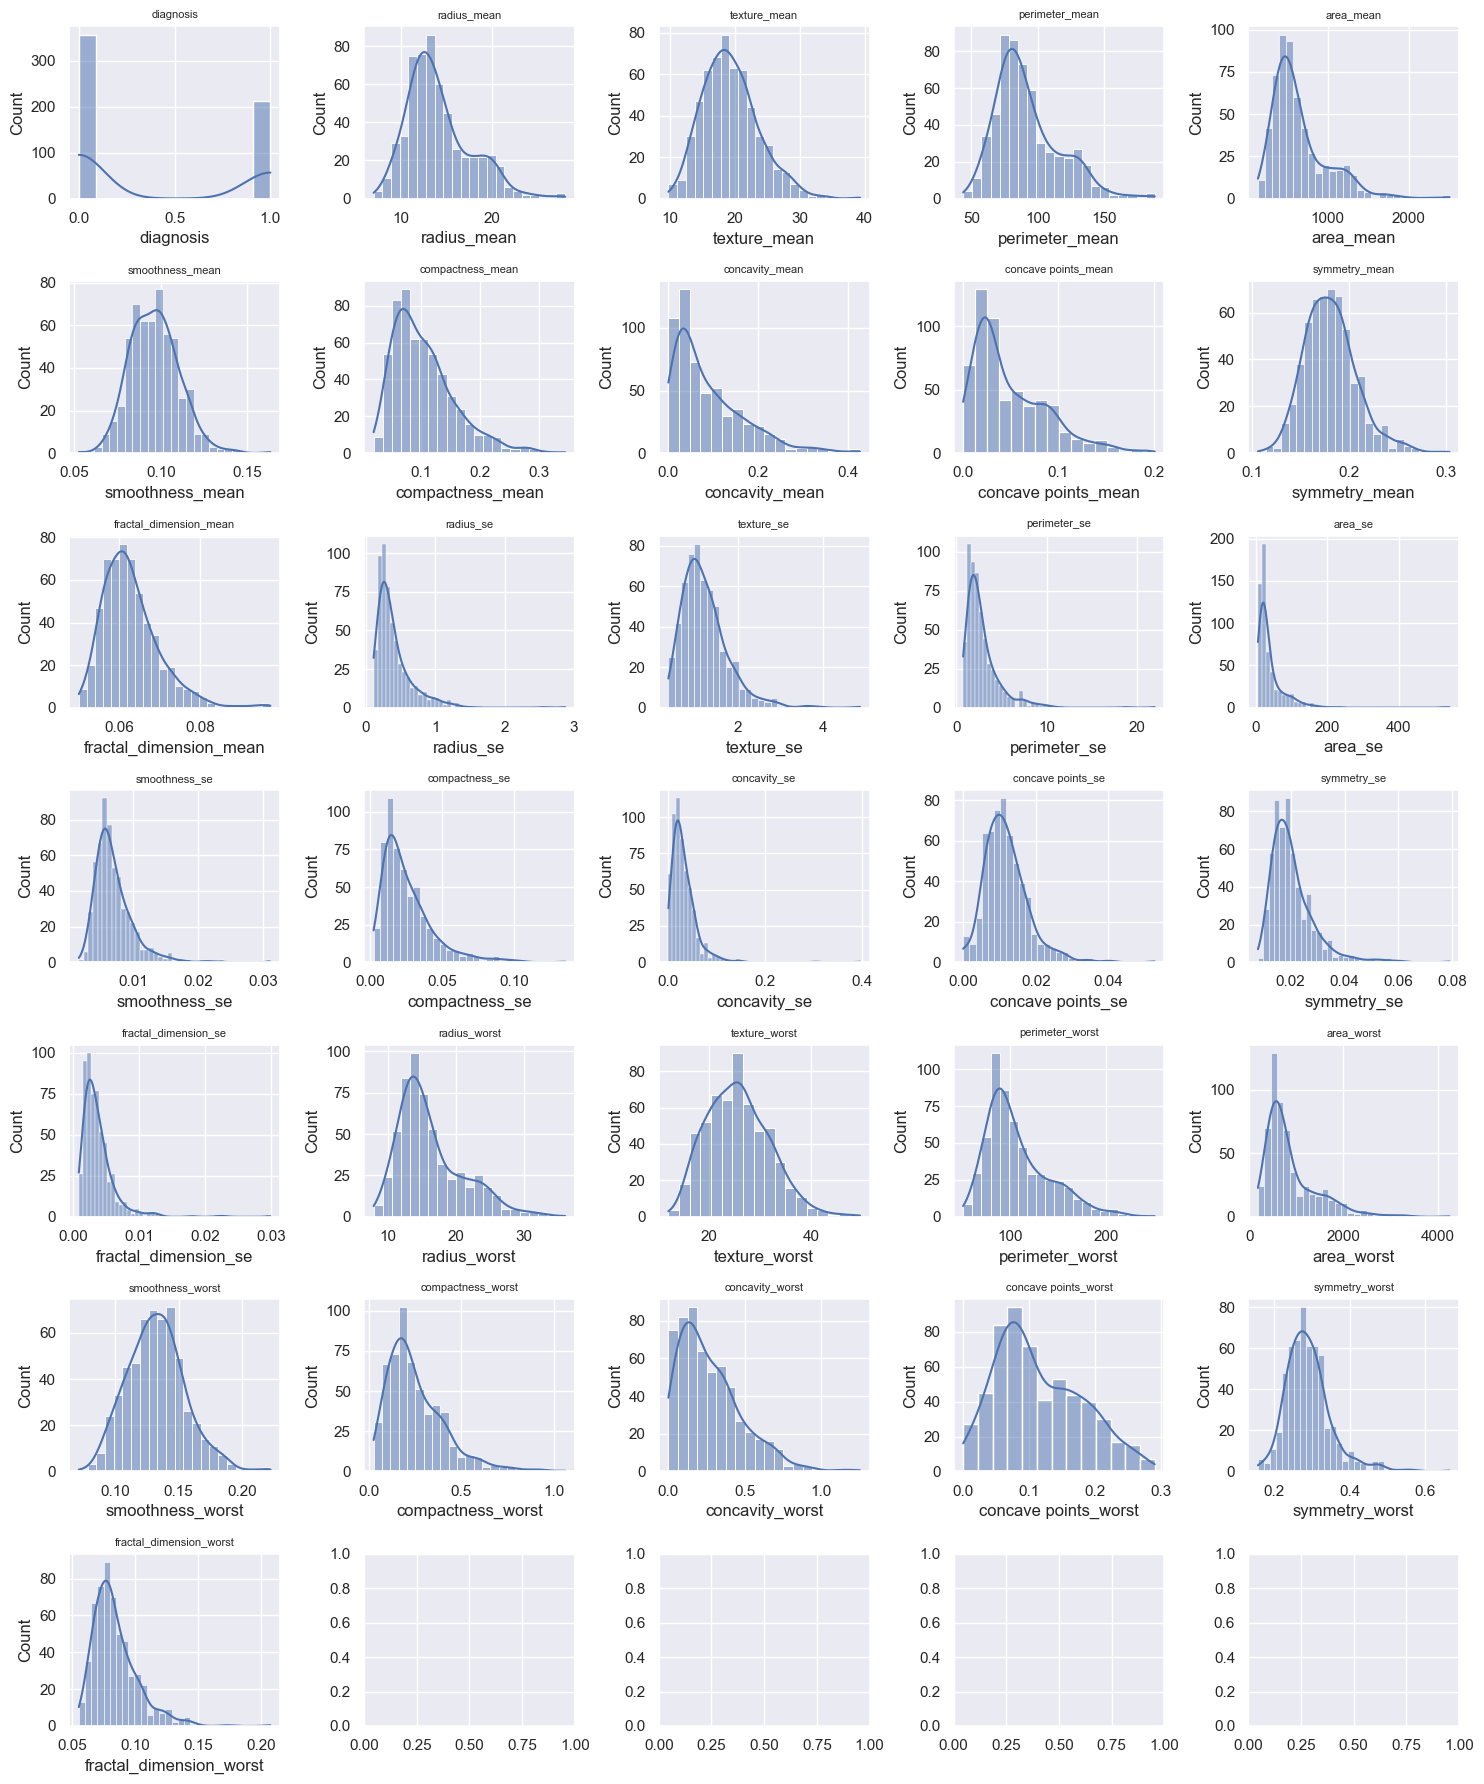

In [48]:
# histogram plot - distribution
fig, axes = plt.subplots(7, 5, figsize = (15, 18))
axes = axes.flatten()
for i,col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize = 8)
plt.tight_layout()
plt.show()

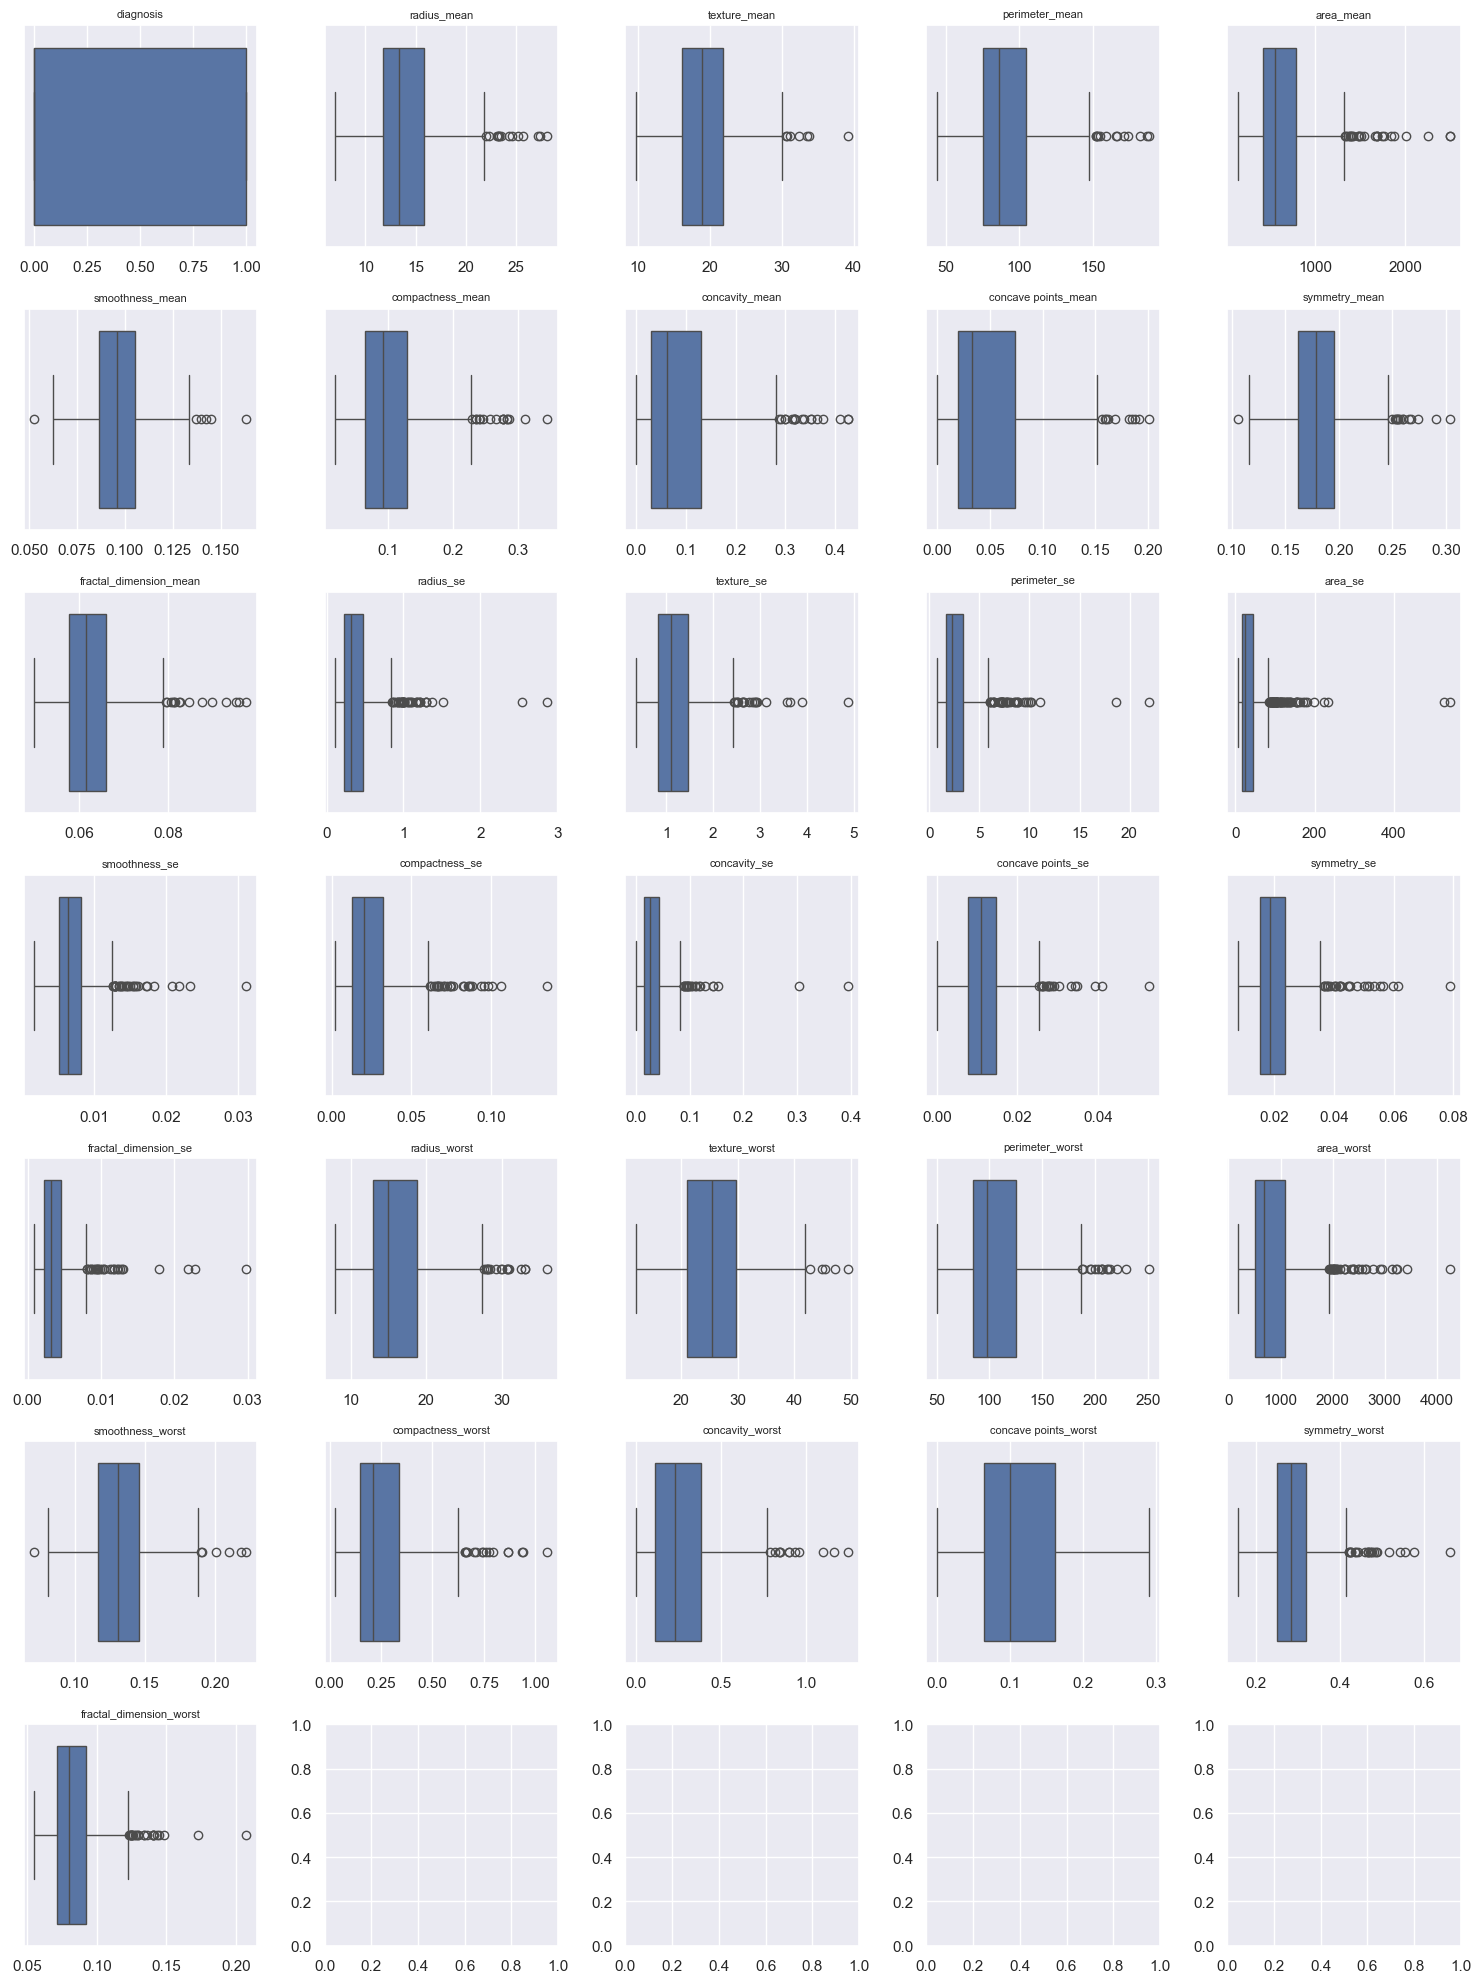

In [56]:
# outliers analysis - boxplot
fig, axes = plt.subplots(7, 5, figsize=(15, 20))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")
plt.tight_layout()
plt.show()

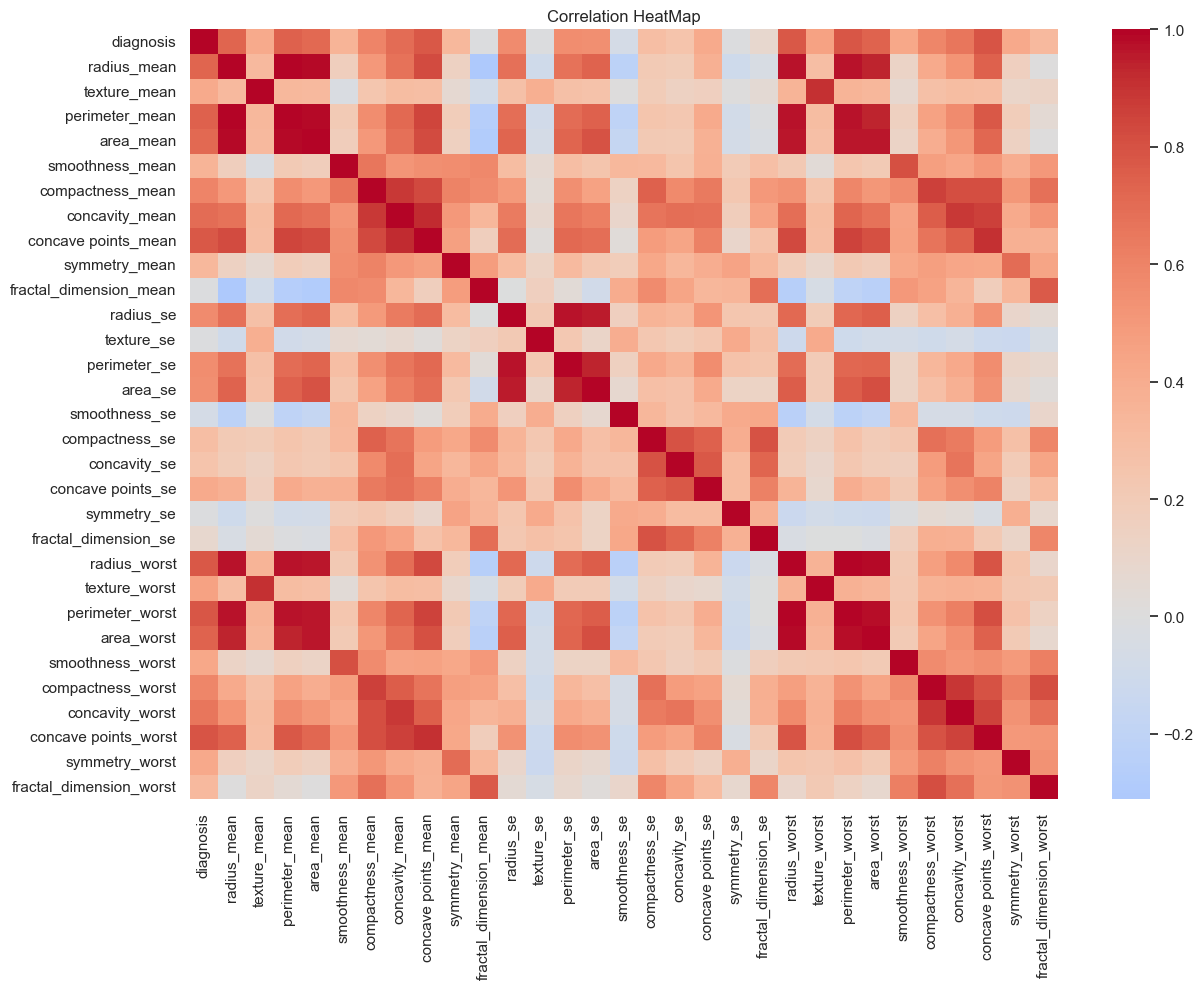

In [55]:
# identify presence of highly correlated columns & feature relationship
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center = 0
)
plt.title("Correlation HeatMap")
plt.show()

**Insights:**
- Drop the id column
- All features are numerical, no categorical variables
- High-dimensional feature space
- No missing values
- Slight class imbalance, address after baseline using precision and recall
- Recall is the priority metric since false negatives are critical
- Strong separation in feature means between classes
- Extreme values often represent malignant cases, not noise
- Highly correlated features present. We can perform feature selection / PCA